In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

In [34]:
df = pd.read_excel('Chronotype_NHANES.xlsx')
df

,Imputation_,Seqn,Sample weight,Strata,Sample Unit,Gender,Age,Race,BMI,Waist_C,...,Trigly,Carb_diet,HSCRP,Smokingstatus,Alcohol,Sleep_hrs,Sleeptime,Wakeuptime,Chronotype_slphrs,WakeUpCat
0,0,83732,NaN,125,1,1,62,2.0,27.8,101.1,...,NaN,126.0,0.6,3.0,1.000000,5.5,23:30:00,05:00:00,3.0,1
1,0,83733,54722.343,125,1,1,53,2.0,30.8,107.9,...,1.660,126.0,1.4,1.0,7.000000,8.0,23:00:00,07:00:00,3.0,3
2,0,83734,25471.094,131,1,1,78,2.0,28.8,116.5,...,3.037,96.0,0.6,3.0,0.000000,7.0,22:30:00,05:30:00,2.0,2
3,0,83735,NaN,131,1,2,56,2.0,42.4,110.1,...,NaN,216.0,9.0,NaN,3.000000,6.5,23:30:00,06:00:00,3.0,2
4,0,83736,38179.511,126,2,2,42,3.0,20.3,80.4,...,0.531,6.0,0.5,NaN,1.000000,NaN,2173-10-13 00:00:00,06:00:00,3.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37945,5,93449,NaN,119,2,1,56,2.0,NaN,NaN,...,NaN,126.0,NaN,2.0,21.174902,8.0,00:00:00,08:00:00,3.0,3
37946,5,93466,NaN,133,2,2,60,1.0,NaN,NaN,...,NaN,0.0,NaN,1.0,8.008570,NaN,2173-10-13 00:00:00,08:00:00,3.0,3
37947,5,93530,NaN,130,2,2,21,4.0,NaN,NaN,...,NaN,1.5,NaN,NaN,NaN,8.0,22:30:00,06:40:00,2.0,3
37948,5,93641,NaN,129,2,2,80,2.0,NaN,NaN,...,NaN,108.0,NaN,NaN,NaN,8.0,22:00:00,06:00:00,2.0,2


In [35]:
df_imp1 = df[df["Imputation_"] == 1].copy()
df_imp1

,Imputation_,Seqn,Sample weight,Strata,Sample Unit,Gender,Age,Race,BMI,Waist_C,...,Trigly,Carb_diet,HSCRP,Smokingstatus,Alcohol,Sleep_hrs,Sleeptime,Wakeuptime,Chronotype_slphrs,WakeUpCat
6325,1,83732,NaN,125,1,1,62,2.0,27.8,101.1,...,NaN,126.0,0.6,3.0,1.000000,5.5,23:30:00,05:00:00,3.0,1
6326,1,83733,54722.343,125,1,1,53,2.0,30.8,107.9,...,1.660,126.0,1.4,1.0,7.000000,8.0,23:00:00,07:00:00,3.0,3
6327,1,83734,25471.094,131,1,1,78,2.0,28.8,116.5,...,3.037,96.0,0.6,3.0,0.000000,7.0,22:30:00,05:30:00,2.0,2
6328,1,83735,NaN,131,1,2,56,2.0,42.4,110.1,...,NaN,216.0,9.0,3.0,3.000000,6.5,23:30:00,06:00:00,3.0,2
6329,1,83736,38179.511,126,2,2,42,3.0,20.3,80.4,...,0.531,6.0,0.5,3.0,1.000000,NaN,2173-10-13 00:00:00,06:00:00,3.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12645,1,93449,NaN,119,2,1,56,2.0,NaN,NaN,...,NaN,126.0,NaN,2.0,20.174956,8.0,00:00:00,08:00:00,3.0,3
12646,1,93466,NaN,133,2,2,60,1.0,NaN,NaN,...,NaN,0.0,NaN,1.0,71.523019,NaN,2173-10-13 00:00:00,08:00:00,3.0,3
12647,1,93530,NaN,130,2,2,21,4.0,NaN,NaN,...,NaN,1.5,NaN,NaN,NaN,8.0,22:30:00,06:40:00,2.0,3
12648,1,93641,NaN,129,2,2,80,2.0,NaN,NaN,...,NaN,108.0,NaN,NaN,NaN,8.0,22:00:00,06:00:00,2.0,2


In [36]:
# Save to Excel
df_imp1.to_excel("Chronotype_NHANES_Imputation1.xlsx", index=False)

# (optional) Save to CSV instead
df_imp1.to_csv("Chronotype_NHANES_Imputation1.csv", index=False)

In [37]:
null_count = df_imp1.isna().sum()
null_pct = (null_count / len(df_imp1) * 100).round(2)

pd.DataFrame({
    "null_count": null_count,
    "null_pct": null_pct
}).sort_values("null_count", ascending=False)

,null_count,null_pct
Trigly,3835,60.63
Sample weight,3441,54.40
Smokingstatus,1745,27.59
Alcohol,1745,27.59
Systolic,716,11.32
Diastolic,716,11.32
HSCRP,660,10.43
Waist_C,645,10.20
BMI,341,5.39
Sleep_hrs,31,0.49


In [38]:
cols_to_drop = ['Sample weight', 'Strata', 'Sample Unit', 'Imputation_','Trigly']
df_imp1 = df_imp1.drop(columns=cols_to_drop)
display(df_imp1.head())
display(df_imp1.info())

,Seqn,Gender,Age,Race,BMI,Waist_C,Systolic,Diastolic,Carb_diet,HSCRP,Smokingstatus,Alcohol,Sleep_hrs,Sleeptime,Wakeuptime,Chronotype_slphrs,WakeUpCat
6325,83732,1,62,2.0,27.8,101.1,122.6667,65.33334,126.0,0.6,3.0,1.0,5.5,23:30:00,05:00:00,3.0,1
6326,83733,1,53,2.0,30.8,107.9,140.0000,86.00000,126.0,1.4,1.0,7.0,8.0,23:00:00,07:00:00,3.0,3
6327,83734,1,78,2.0,28.8,116.5,135.3333,45.33333,96.0,0.6,3.0,0.0,7.0,22:30:00,05:30:00,2.0,2
6328,83735,2,56,2.0,42.4,110.1,134.0000,70.00000,216.0,9.0,3.0,3.0,6.5,23:30:00,06:00:00,3.0,2
6329,83736,2,42,3.0,20.3,80.4,104.0000,60.00000,6.0,0.5,3.0,1.0,NaN,2173-10-13 00:00:00,06:00:00,3.0,2


<class 'pandas.core.frame.DataFrame'>
Index: 6325 entries, 6325 to 12649
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Seqn               6325 non-null   int64  
 1   Gender             6325 non-null   int64  
 2   Age                6325 non-null   int64  
 3   Race               6324 non-null   float64
 4   BMI                5984 non-null   float64
 5   Waist_C            5680 non-null   float64
 6   Systolic           5609 non-null   float64
 7   Diastolic          5609 non-null   float64
 8   Carb_diet          6325 non-null   float64
 9   HSCRP              5665 non-null   float64
 10  Smokingstatus      4580 non-null   float64
 11  Alcohol            4580 non-null   float64
 12  Sleep_hrs          6294 non-null   float64
 13  Sleeptime          6325 non-null   object 
 14  Wakeuptime         6325 non-null   object 
 15  Chronotype_slphrs  6319 non-null   float64
 16  WakeUpCat          6325 n

None

In [39]:
df_imp1['Alcohol'] = df_imp1['Alcohol'].fillna(-1)
df_imp1['Smokingstatus'] = df_imp1['Smokingstatus'].fillna(-1)

print("Null counts after filling:")
display(df_imp1[['Alcohol', 'Smokingstatus']].isnull().sum())
display(df_imp1.head())

Null counts after filling:


Alcohol          0
Smokingstatus    0
dtype: int64

,Seqn,Gender,Age,Race,BMI,Waist_C,Systolic,Diastolic,Carb_diet,HSCRP,Smokingstatus,Alcohol,Sleep_hrs,Sleeptime,Wakeuptime,Chronotype_slphrs,WakeUpCat
6325,83732,1,62,2.0,27.8,101.1,122.6667,65.33334,126.0,0.6,3.0,1.0,5.5,23:30:00,05:00:00,3.0,1
6326,83733,1,53,2.0,30.8,107.9,140.0000,86.00000,126.0,1.4,1.0,7.0,8.0,23:00:00,07:00:00,3.0,3
6327,83734,1,78,2.0,28.8,116.5,135.3333,45.33333,96.0,0.6,3.0,0.0,7.0,22:30:00,05:30:00,2.0,2
6328,83735,2,56,2.0,42.4,110.1,134.0000,70.00000,216.0,9.0,3.0,3.0,6.5,23:30:00,06:00:00,3.0,2
6329,83736,2,42,3.0,20.3,80.4,104.0000,60.00000,6.0,0.5,3.0,1.0,NaN,2173-10-13 00:00:00,06:00:00,3.0,2


In [40]:
df = df_imp1

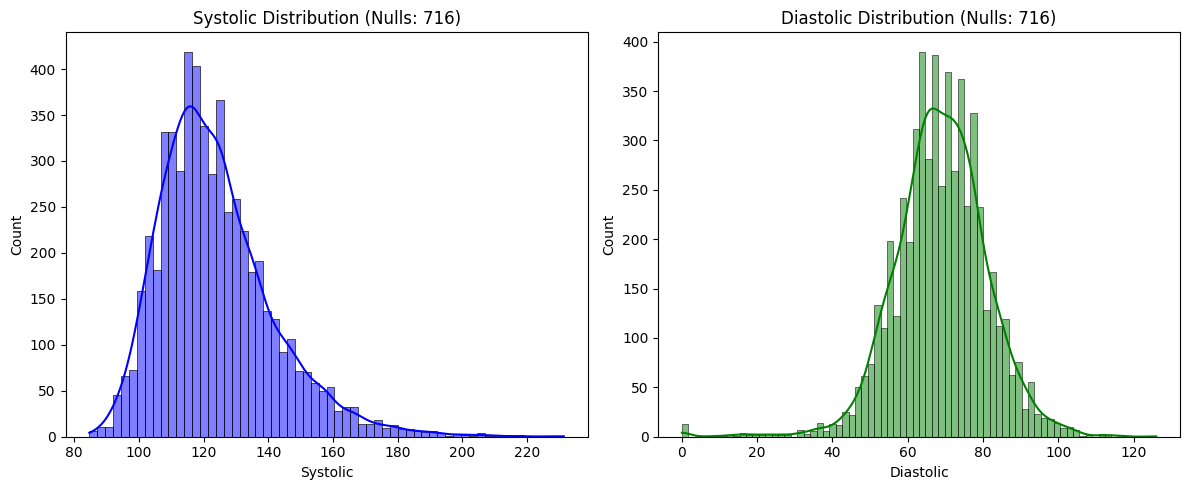

Summary Statistics:


,Systolic,Diastolic
count,5609.000000,5609.000000
mean,123.729839,68.762108
std,17.774976,12.392105
min,84.666660,0.000000
25%,111.333300,61.333330
50%,120.666700,68.666660
75%,133.333300,76.666660
max,231.333300,126.000000


In [41]:
# Check distribution of Systolic and Diastolic columns
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['Systolic'].dropna(), kde=True, color='blue')
plt.title(f"Systolic Distribution (Nulls: {df['Systolic'].isnull().sum()})")

plt.subplot(1, 2, 2)
sns.histplot(df['Diastolic'].dropna(), kde=True, color='green')
plt.title(f"Diastolic Distribution (Nulls: {df['Diastolic'].isnull().sum()})")

plt.tight_layout()
plt.show()

print("Summary Statistics:")
display(df[['Systolic', 'Diastolic']].describe())

In [42]:
import pandas as pd
from sklearn.impute import KNNImputer

# Assuming your dataframe is currently named 'df'
# It's best practice to only use relevant numeric columns for the KNN calculation
df = df.reset_index(drop=True)
features_for_imputation = ['Age', 'Gender', 'BMI', 'Systolic', 'Diastolic']

# Isolate the columns we want to use
df_bp = df[features_for_imputation].copy()

# Initialize the imputer (looking at the 5 most similar participants)
knn_imputer = KNNImputer(n_neighbors=5)

# Apply the imputation
df_bp_imputed = pd.DataFrame(knn_imputer.fit_transform(df_bp), columns=df_bp.columns)

# Put the cleaned columns back into your main dataframe
df['Systolic'] = df_bp_imputed['Systolic']
df['Diastolic'] = df_bp_imputed['Diastolic']

print(df[['Systolic', 'Diastolic']].isnull().sum()) # Should now print 0

Systolic     0
Diastolic    0
dtype: int64


In [43]:
null_count = df.isna().sum()
null_pct = (null_count / len(df) * 100).round(2)

pd.DataFrame({
    "null_count": null_count,
    "null_pct": null_pct
}).sort_values("null_count", ascending=False)

,null_count,null_pct
HSCRP,660,10.43
Waist_C,645,10.20
BMI,341,5.39
Sleep_hrs,31,0.49
Chronotype_slphrs,6,0.09
Race,1,0.02
Seqn,0,0.00
Gender,0,0.00
Age,0,0.00
Carb_diet,0,0.00


In [44]:
# Save to Excel
df.to_excel("Chronotype_NHANES_Imputation1.xlsx", index=False)

# (optional) Save to CSV instead
df.to_csv("Chronotype_NHANES_Imputation1.csv", index=False)

In [45]:
# 2. DROP rows where BOTH BMI and Waist_C are missing
df = df.dropna(subset=['BMI', 'Waist_C'], how='all')

# 3. Setup KNN for the remaining ones that only miss ONE of the two
features_for_physicals = ['Age', 'Gender', 'BMI', 'Waist_C']
df_phys = df[features_for_physicals].copy()

knn_imputer = KNNImputer(n_neighbors=5)
phys_imputed_array = knn_imputer.fit_transform(df_phys)

# 4. Put the cleanly imputed columns back into your main dataset
df_phys_imputed = pd.DataFrame(phys_imputed_array, columns=df_phys.columns, index=df.index)

df['BMI'] = df_phys_imputed['BMI']
df['Waist_C'] = df_phys_imputed['Waist_C']

# Verify they are now completely clean!
print("Remaining nulls in BMI:", df['BMI'].isnull().sum())
print("Remaining nulls in Waist_C:", df['Waist_C'].isnull().sum())

Remaining nulls in BMI: 0
Remaining nulls in Waist_C: 0


In [46]:
# Drop the rows with missing values in our target and tiny-fraction columns
df = df.dropna(subset=['HSCRP', 'Sleep_hrs', 'Chronotype_slphrs', 'Race'])
df = df.reset_index(drop=True)
# The moment of truth! This should print all zeros.
print(df.isnull().sum())

Seqn                 0
Gender               0
Age                  0
Race                 0
BMI                  0
Waist_C              0
Systolic             0
Diastolic            0
Carb_diet            0
HSCRP                0
Smokingstatus        0
Alcohol              0
Sleep_hrs            0
Sleeptime            0
Wakeuptime           0
Chronotype_slphrs    0
WakeUpCat            0
dtype: int64


In [47]:
# Save to Excel
df.to_excel("Chronotype_NHANES_Imputation1.xlsx", index=False)

# (optional) Save to CSV instead
df.to_csv("Chronotype_NHANES_Imputation1.csv", index=False)

In [48]:
display(df.head())
display(df.info())

,Seqn,Gender,Age,Race,BMI,Waist_C,Systolic,Diastolic,Carb_diet,HSCRP,Smokingstatus,Alcohol,Sleep_hrs,Sleeptime,Wakeuptime,Chronotype_slphrs,WakeUpCat
0,83732,1,62,2.0,27.8,101.1,122.6667,65.33334,126.0,0.6,3.0,1.0,5.5,23:30:00,05:00:00,3.0,1
1,83733,1,53,2.0,30.8,107.9,140.0000,86.00000,126.0,1.4,1.0,7.0,8.0,23:00:00,07:00:00,3.0,3
2,83734,1,78,2.0,28.8,116.5,135.3333,45.33333,96.0,0.6,3.0,0.0,7.0,22:30:00,05:30:00,2.0,2
3,83735,2,56,2.0,42.4,110.1,134.0000,70.00000,216.0,9.0,3.0,3.0,6.5,23:30:00,06:00:00,3.0,2
4,83741,1,22,3.0,28.0,86.6,111.3333,72.66666,5.5,1.3,2.0,3.0,6.5,23:00:00,05:30:00,3.0,2


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5587 entries, 0 to 5586
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Seqn               5587 non-null   int64  
 1   Gender             5587 non-null   int64  
 2   Age                5587 non-null   int64  
 3   Race               5587 non-null   float64
 4   BMI                5587 non-null   float64
 5   Waist_C            5587 non-null   float64
 6   Systolic           5587 non-null   float64
 7   Diastolic          5587 non-null   float64
 8   Carb_diet          5587 non-null   float64
 9   HSCRP              5587 non-null   float64
 10  Smokingstatus      5587 non-null   float64
 11  Alcohol            5587 non-null   float64
 12  Sleep_hrs          5587 non-null   float64
 13  Sleeptime          5587 non-null   object 
 14  Wakeuptime         5587 non-null   object 
 15  Chronotype_slphrs  5587 non-null   float64
 16  WakeUpCat          5587 

None

In [52]:
n_rows, n_cols = df.shape
print(f" DataFrame Summary")
print(f"   Rows:    {n_rows:,}")
print(f"   Columns: {n_cols}")
print(f"   Shape:   {df.shape}")

 DataFrame Summary
   Rows:    5,587
   Columns: 17
   Shape:   (5587, 17)


In [58]:
from IPython.display import Markdown, display

report = f"""
### Dataset Overview

| Metric | Value |
|--------|-------|
| **Total Rows** | {n_rows:,} |
| **Total Columns** | {n_cols} |
| **Data Points** | {n_rows * n_cols:,} |
| **Memory Usage** | {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB |
| **Numeric Features** | {df.select_dtypes(include=['number']).shape[1]} |
| **Categorical Features** | {df.select_dtypes(include=['object']).shape[1]} |
"""
display(Markdown(report))


### Dataset Overview

| Metric | Value |
|--------|-------|
| **Total Rows** | 5,587 |
| **Total Columns** | 17 |
| **Data Points** | 94,979 |
| **Memory Usage** | 1.15 MB |
| **Numeric Features** | 15 |
| **Categorical Features** | 2 |
